# Charades-Ego Analysis — Track 7 / Domain Adaptation Exo→Ego

Five figures supporting Sections 4.4, 5.1, 5.3, 5.4 of the REPORT:

- **Fig 9** — Training curves: val balanced acc over epochs for B1/DANN/MMD/B2 (Section 4.4)
- **Fig 10** — DANN diagnostic 2×2 (`dom_acc`, `λ_p`, `L_cls`, `L_dom`) confirming GRL convergence (Section 5.1)
- **Fig 11** — t-SNE of encoder embeddings under each model (Section 5.3)
- **Fig 12** — Per-class gap (B2 − B1) showing which actions resist transfer (Section 5.4)
- **Fig 13** — Confusion-matrix differential (CM_DANN − CM_B1) showing where DANN gains and loses (Section 5.4)

All figures use the official `best.pt` checkpoints under `experiments/checkpoints/CHAR_*` and the val-target split (`val_target.npz`, 5,135 segments).

In [1]:
"""Setup imports, paths, and a small helper to rebuild encoder+classifier
from any of the 4 .pt checkpoints (B1, B2, DANN, MMD).
"""
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from src.models.encoder import FeatureEncoder
from src.models.classifier import ActionClassifier
from src.datasets.charades_ego import CharadesEgoSegmentDataset, NUM_CLASSES

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110

FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR = PROJECT_ROOT / "experiments" / "checkpoints"

# Class names short labels
with open(PROJECT_ROOT / "data" / "raw" / "charades-ego" / "CharadesEgo" / "Charades_v1_classes.txt") as f:
    raw = [l.strip() for l in f if l.strip()]
class_names = [s.split(" ", 1)[1] if " " in s else s for s in raw]

# Model paths
MODELS = {
    "B1":   CKPT_DIR / "CHAR_baseline_source_only" / "best.pt",
    "DANN": CKPT_DIR / "CHAR_dann_lambda05"        / "best.pt",
    "MMD":  CKPT_DIR / "CHAR_mmd_lambda10"         / "best.pt",
    "B2":   CKPT_DIR / "CHAR_baseline_target_only" / "best.pt",
}
TB_DIRS = {k: p.parent / "tb" for k, p in MODELS.items()}
COLORS  = {"B1": "#1f77b4", "DANN": "#d62728", "MMD": "#2ca02c", "B2": "#ff7f0e"}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Num classes: {NUM_CLASSES}")


def build_from_ckpt(ckpt_path: Path, in_dim: int = 2048, embed_dim: int = 256,
                    num_classes: int = 157, device: torch.device = device):
    """Rebuild encoder + classifier from a checkpoint, regardless of whether
    the checkpoint was produced by trainer_supervised, trainer_dann, or trainer_mmd.

    Strategy: filter state_dict on prefixes 'encoder.' and 'classifier.'.
    Discriminator and GRL weights (DANN only) are ignored.
    Classifier hidden dim is inferred from the shape of `classifier.net.0.weight`.
    """
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    sd = ckpt["state_dict"]

    enc_sd = {k[len("encoder."):]: v for k, v in sd.items() if k.startswith("encoder.")}
    cls_sd = {k[len("classifier."):]: v for k, v in sd.items() if k.startswith("classifier.")}

    # Infer classifier hidden dim from first linear layer
    # The first Linear is classifier.net.0 -> 'net.0.weight' shape = (hidden_dim, embed_dim)
    first_w = cls_sd["net.0.weight"]
    cls_hidden = int(first_w.shape[0])

    encoder = FeatureEncoder(in_dim=in_dim, hidden_dims=(1024, 512),
                             embed_dim=embed_dim, dropout=0.3).to(device)
    classifier = ActionClassifier(embed_dim=embed_dim, hidden_dim=cls_hidden,
                                  num_classes=num_classes, dropout=0.1).to(device)

    encoder.load_state_dict(enc_sd)
    classifier.load_state_dict(cls_sd)
    encoder.eval()
    classifier.eval()
    return encoder, classifier, ckpt.get("epoch", -1), ckpt.get("best_metric", float("nan")), cls_hidden


# Sanity: load each model and print a one-liner
for name, path in MODELS.items():
    enc, cls, epoch, best_m, cls_hidden = build_from_ckpt(path)
    n_enc = sum(p.numel() for p in enc.parameters())
    n_cls = sum(p.numel() for p in cls.parameters())
    print(f"{name:5s} loaded: best_metric={best_m:.4f} at epoch={epoch:2d} "
          f"| cls_hidden={cls_hidden} | encoder {n_enc/1e6:.2f}M params, "
          f"classifier {n_cls/1e6:.2f}M params")

Device: cuda
Project root: c:\Users\massi\Documents\GitHub\dl26-projects
Num classes: 157
B1    loaded: best_metric=0.0391 at epoch=29 | cls_hidden=256 | encoder 2.76M params, classifier 0.11M params
DANN  loaded: best_metric=0.0401 at epoch=23 | cls_hidden=128 | encoder 2.76M params, classifier 0.05M params
MMD   loaded: best_metric=0.0425 at epoch=20 | cls_hidden=256 | encoder 2.76M params, classifier 0.11M params
B2    loaded: best_metric=0.0683 at epoch=16 | cls_hidden=256 | encoder 2.76M params, classifier 0.11M params


In [2]:
"""Forward the val_target split through every model's encoder & classifier;
cache embeddings + logits + labels for downstream figures (no need to
re-do the forward pass in each cell).
"""
val_npz = PROJECT_ROOT / "data" / "processed" / "charades-ego" / "segment_features" / "val_target.npz"
val_ds = CharadesEgoSegmentDataset(val_npz)
print(f"Val target: {len(val_ds):,} segments, num_classes={val_ds.num_classes}, feature_dim={val_ds.feature_dim}\n")

# Load all features into RAM once
X_val = val_ds.features.to(device)        # (N, 2048)
y_val = val_ds.labels.numpy()             # (N,) int64
print(f"X_val on {device}: shape={tuple(X_val.shape)}, dtype={X_val.dtype}")

EMBEDDINGS = {}
LOGITS     = {}
for name, path in MODELS.items():
    enc, cls, _, _, _ = build_from_ckpt(path)
    with torch.no_grad():
        z = enc(X_val)              # (N, 256)
        logits = cls(z)             # (N, 157)
    EMBEDDINGS[name] = z.cpu().numpy()
    LOGITS[name]     = logits.cpu().numpy()
    preds = logits.argmax(dim=1).cpu().numpy()
    top1 = float((preds == y_val).mean())
    print(f"{name:5s}: embeddings {EMBEDDINGS[name].shape}, logits {LOGITS[name].shape}, top-1={top1:.4f}")

print("\nReady. EMBEDDINGS / LOGITS / y_val available for the rest of the notebook.")

Val target: 5,135 segments, num_classes=157, feature_dim=2048

X_val on cuda: shape=(5135, 2048), dtype=torch.float32
B1   : embeddings (5135, 256), logits (5135, 157), top-1=0.0460
DANN : embeddings (5135, 256), logits (5135, 157), top-1=0.0539
MMD  : embeddings (5135, 256), logits (5135, 157), top-1=0.0553
B2   : embeddings (5135, 256), logits (5135, 157), top-1=0.0722

Ready. EMBEDDINGS / LOGITS / y_val available for the rest of the notebook.


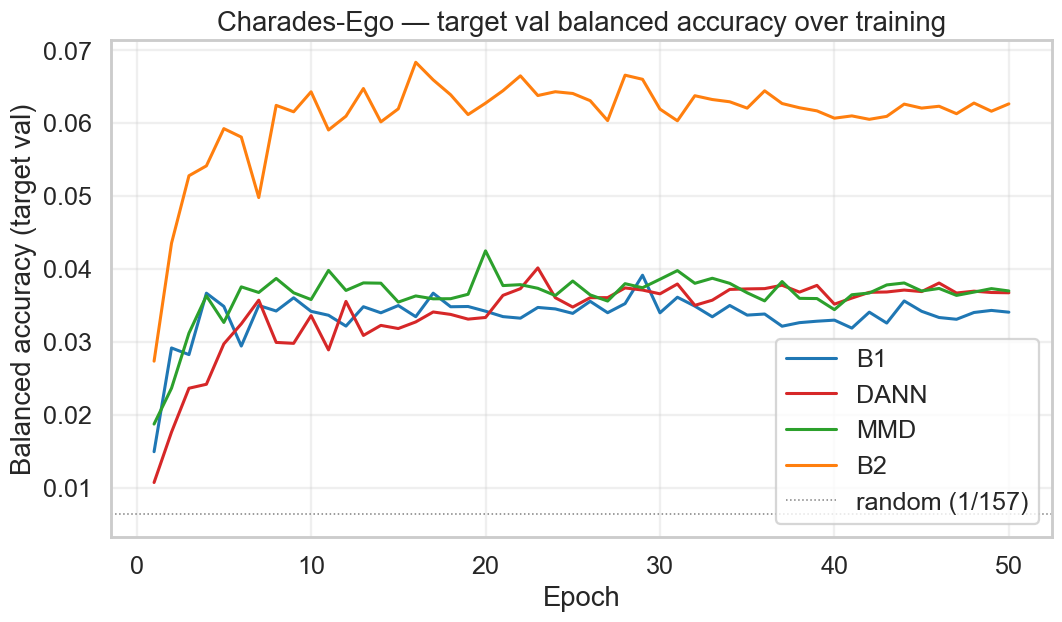

Saved: figures/09_training_curves_balanced_acc.png


In [3]:
"""Figure 9 — val target balanced accuracy over epochs for B1/DANN/MMD/B2.
Reads scalars 'val/balanced_accuracy' from each TensorBoard log.
"""
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator


def read_tb_scalar(tb_dir: Path, tag: str) -> tuple[list[int], list[float]]:
    """Return parallel (steps, values) lists for one scalar tag from a TB dir."""
    # Find the first event file
    event_files = sorted(tb_dir.glob("events.out.tfevents*"))
    if not event_files:
        raise FileNotFoundError(f"No event files in {tb_dir}")
    ea = EventAccumulator(str(event_files[0]), size_guidance={"scalars": 0})
    ea.Reload()
    if tag not in ea.Tags()["scalars"]:
        return [], []
    events = ea.Scalars(tag)
    return [e.step for e in events], [e.value for e in events]


fig, ax = plt.subplots(figsize=(10, 6))
for name in ["B1", "DANN", "MMD", "B2"]:
    steps, vals = read_tb_scalar(TB_DIRS[name], "val/balanced_accuracy")
    if not steps:
        print(f"  [WARN] no val/balanced_accuracy in {TB_DIRS[name]}")
        continue
    ax.plot(steps, vals, label=name, color=COLORS[name], linewidth=2.0)

# horizontal "random guess" reference
ax.axhline(y=1.0 / 157, color="gray", linestyle=":", linewidth=1.0, label="random (1/157)")

ax.set_xlabel("Epoch")
ax.set_ylabel("Balanced accuracy (target val)")
ax.set_title("Charades-Ego — target val balanced accuracy over training")
ax.legend(loc="best", frameon=True)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "09_training_curves_balanced_acc.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: figures/09_training_curves_balanced_acc.png")

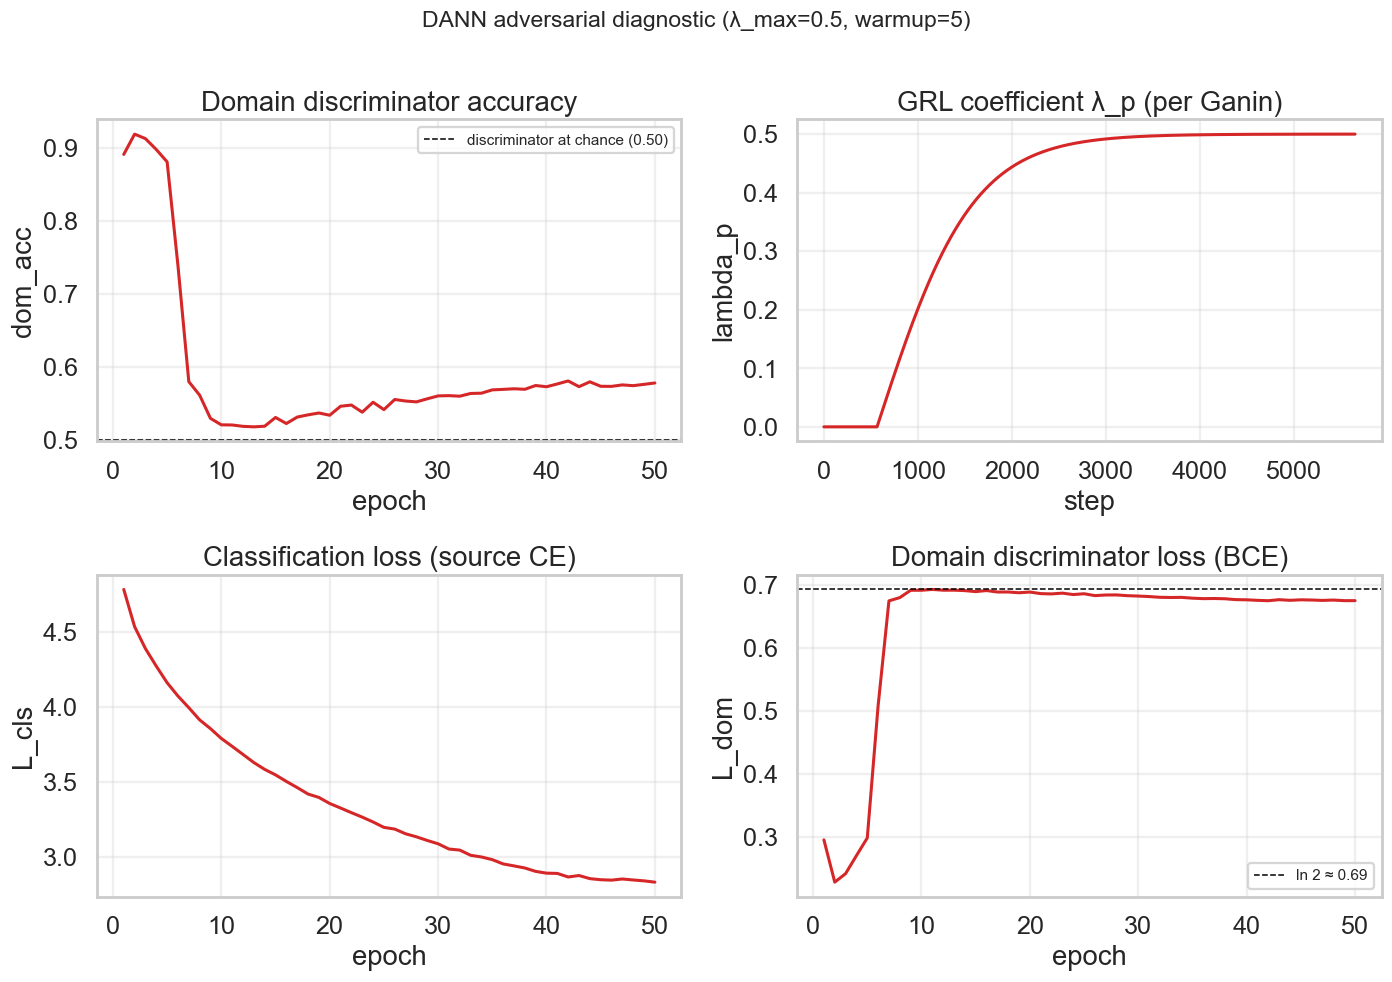

Saved: figures/10_dann_diagnostic.png

Key landing values (last epochs):
  epoch/dom_acc             epoch 1: 0.891   epoch -1: 0.578
  epoch/L_dom               epoch 1: 0.295   epoch -1: 0.675
  epoch/L_cls               epoch 1: 4.785   epoch -1: 2.832
  epoch/src_top1            epoch 1: 0.035   epoch -1: 0.192


In [4]:
"""Figure 10 — DANN diagnostic 2×2.

Confirms that the adversarial dynamics behave as predicted by Ganin et al.:
    dom_acc  : converges from ~0.9 to ~0.5 once GRL is active
    lambda_p : ramped per Ganin schedule from 0 to lambda_max
    L_cls    : drops monotonically (encoder + classifier on source)
    L_dom    : converges to ≈ ln 2 ≈ 0.69 (discriminator at chance)
"""
dann_tb = TB_DIRS["DANN"]

# epoch-level scalars from DANN
epoch_tags = {
    "L_cls":   "epoch/L_cls",
    "L_dom":   "epoch/L_dom",
    "dom_acc": "epoch/dom_acc",
}
# step-level: lambda
step_lambda = read_tb_scalar(dann_tb, "step/lambda_p")

panels = [
    ("dom_acc", "Domain discriminator accuracy", "epoch/dom_acc", "epoch", 0.5,
     "discriminator at chance (0.50)"),
    ("lambda_p", "GRL coefficient λ_p (per Ganin)", "step/lambda_p", "step", None, None),
    ("L_cls", "Classification loss (source CE)", "epoch/L_cls", "epoch", None, None),
    ("L_dom", "Domain discriminator loss (BCE)", "epoch/L_dom", "epoch", np.log(2),
     "ln 2 ≈ 0.69"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (key, title, tag, xlabel, refline, ref_label) in zip(axes.flat, panels):
    steps, vals = read_tb_scalar(dann_tb, tag)
    if not steps:
        ax.text(0.5, 0.5, f"missing: {tag}", ha="center", va="center")
        continue
    ax.plot(steps, vals, color="#d62728", linewidth=2.0)
    if refline is not None:
        ax.axhline(y=refline, color="black", linestyle="--", linewidth=1.0,
                   label=ref_label)
        ax.legend(loc="best", frameon=True, fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(key)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

fig.suptitle("DANN adversarial diagnostic (λ_max=0.5, warmup=5)", fontsize=15, y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / "10_dann_diagnostic.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: figures/10_dann_diagnostic.png")

# also print the key landing values for the REPORT
print("\nKey landing values (last epochs):")
for tag in ["epoch/dom_acc", "epoch/L_dom", "epoch/L_cls", "epoch/src_top1"]:
    s, v = read_tb_scalar(dann_tb, tag)
    if v:
        print(f"  {tag:25s} epoch 1: {v[0]:.3f}   epoch -1: {v[-1]:.3f}")

Subsampled: 1500 source + 1500 target = 3000 points
  B1: t-SNE on 3000 embeddings... done.
  DANN: t-SNE on 3000 embeddings... done.
  MMD: t-SNE on 3000 embeddings... done.
  B2: t-SNE on 3000 embeddings... done.


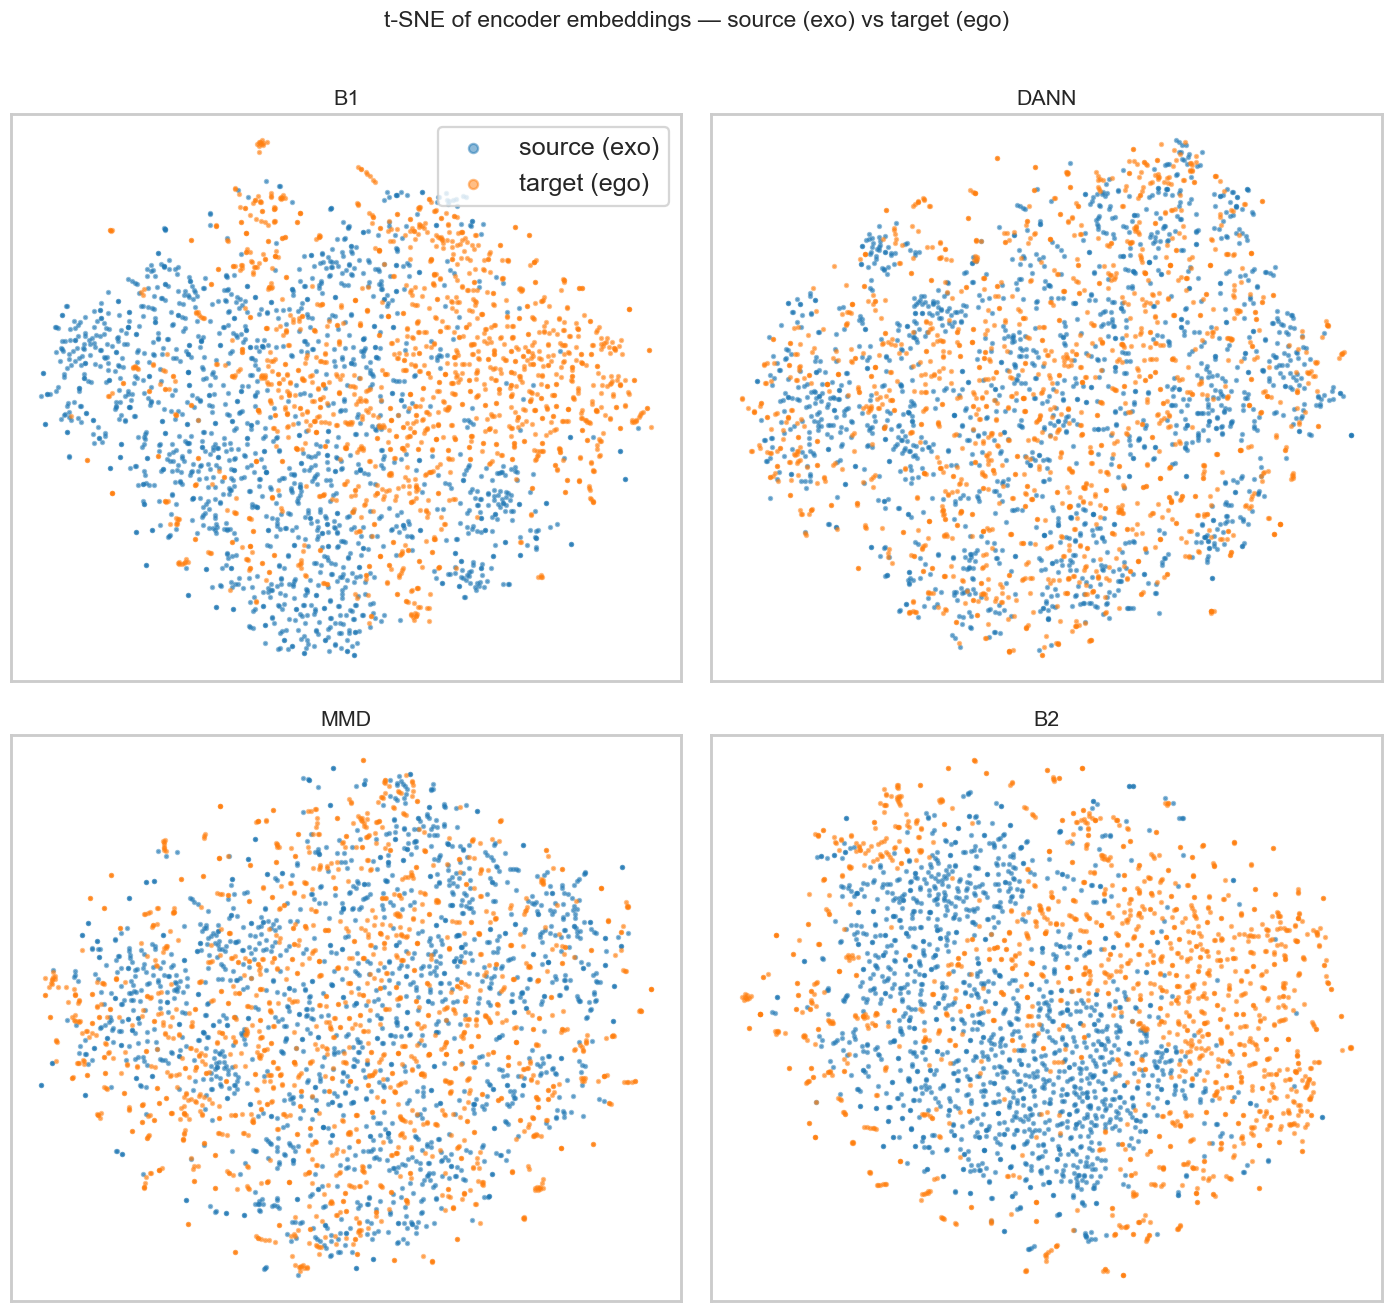

Saved: figures/11_tsne_embeddings.png


In [5]:
"""Figure 11 — t-SNE 2D of encoder embeddings under each model.

For each model (B1, DANN, MMD, B2):
  - subsample ~2000 segments (stratified by class)
  - compute embeddings, run t-SNE to 2D
  - plot colouring by domain (source=blue, target=orange)
"""
from sklearn.manifold import TSNE

# we need source AND target embeddings to show the domain alignment
src_npz = PROJECT_ROOT / "data" / "processed" / "charades-ego" / "segment_features" / "train_source.npz"
src_ds = CharadesEgoSegmentDataset(src_npz)

# subsample for t-SNE speed
rng = np.random.default_rng(42)
N_SUB = 1500
src_idx = rng.choice(len(src_ds), size=N_SUB, replace=False)
tgt_idx = rng.choice(len(val_ds), size=N_SUB, replace=False)

X_src_sub = src_ds.features[src_idx].to(device)
X_tgt_sub = val_ds.features[tgt_idx].to(device)
y_src_sub = src_ds.labels[src_idx].numpy()
y_tgt_sub = val_ds.labels[tgt_idx].numpy()

print(f"Subsampled: {N_SUB} source + {N_SUB} target = {2*N_SUB} points")

fig, axes = plt.subplots(2, 2, figsize=(13, 12))
for ax, name in zip(axes.flat, ["B1", "DANN", "MMD", "B2"]):
    enc, _, _, _, _ = build_from_ckpt(MODELS[name])
    with torch.no_grad():
        z_src = enc(X_src_sub).cpu().numpy()
        z_tgt = enc(X_tgt_sub).cpu().numpy()
    Z = np.concatenate([z_src, z_tgt], axis=0)
    dom = np.array([0]*N_SUB + [1]*N_SUB)  # 0=src, 1=tgt
    
    print(f"  {name}: t-SNE on {len(Z)} embeddings...", end=" ", flush=True)
    tsne = TSNE(n_components=2, perplexity=30, init="pca",
                random_state=42, max_iter=1000, learning_rate="auto", n_jobs=-1)
    Z2 = tsne.fit_transform(Z)
    print("done.")
    
    ax.scatter(Z2[dom==0, 0], Z2[dom==0, 1], s=4, c="#1f77b4", alpha=0.5, label="source (exo)")
    ax.scatter(Z2[dom==1, 0], Z2[dom==1, 1], s=4, c="#ff7f0e", alpha=0.5, label="target (ego)")
    ax.set_title(name, fontsize=14)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel(""); ax.set_ylabel("")
    if name == "B1":
        ax.legend(loc="upper right", markerscale=3, frameon=True)

fig.suptitle("t-SNE of encoder embeddings — source (exo) vs target (ego)", fontsize=15, y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / "11_tsne_embeddings.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: figures/11_tsne_embeddings.png")

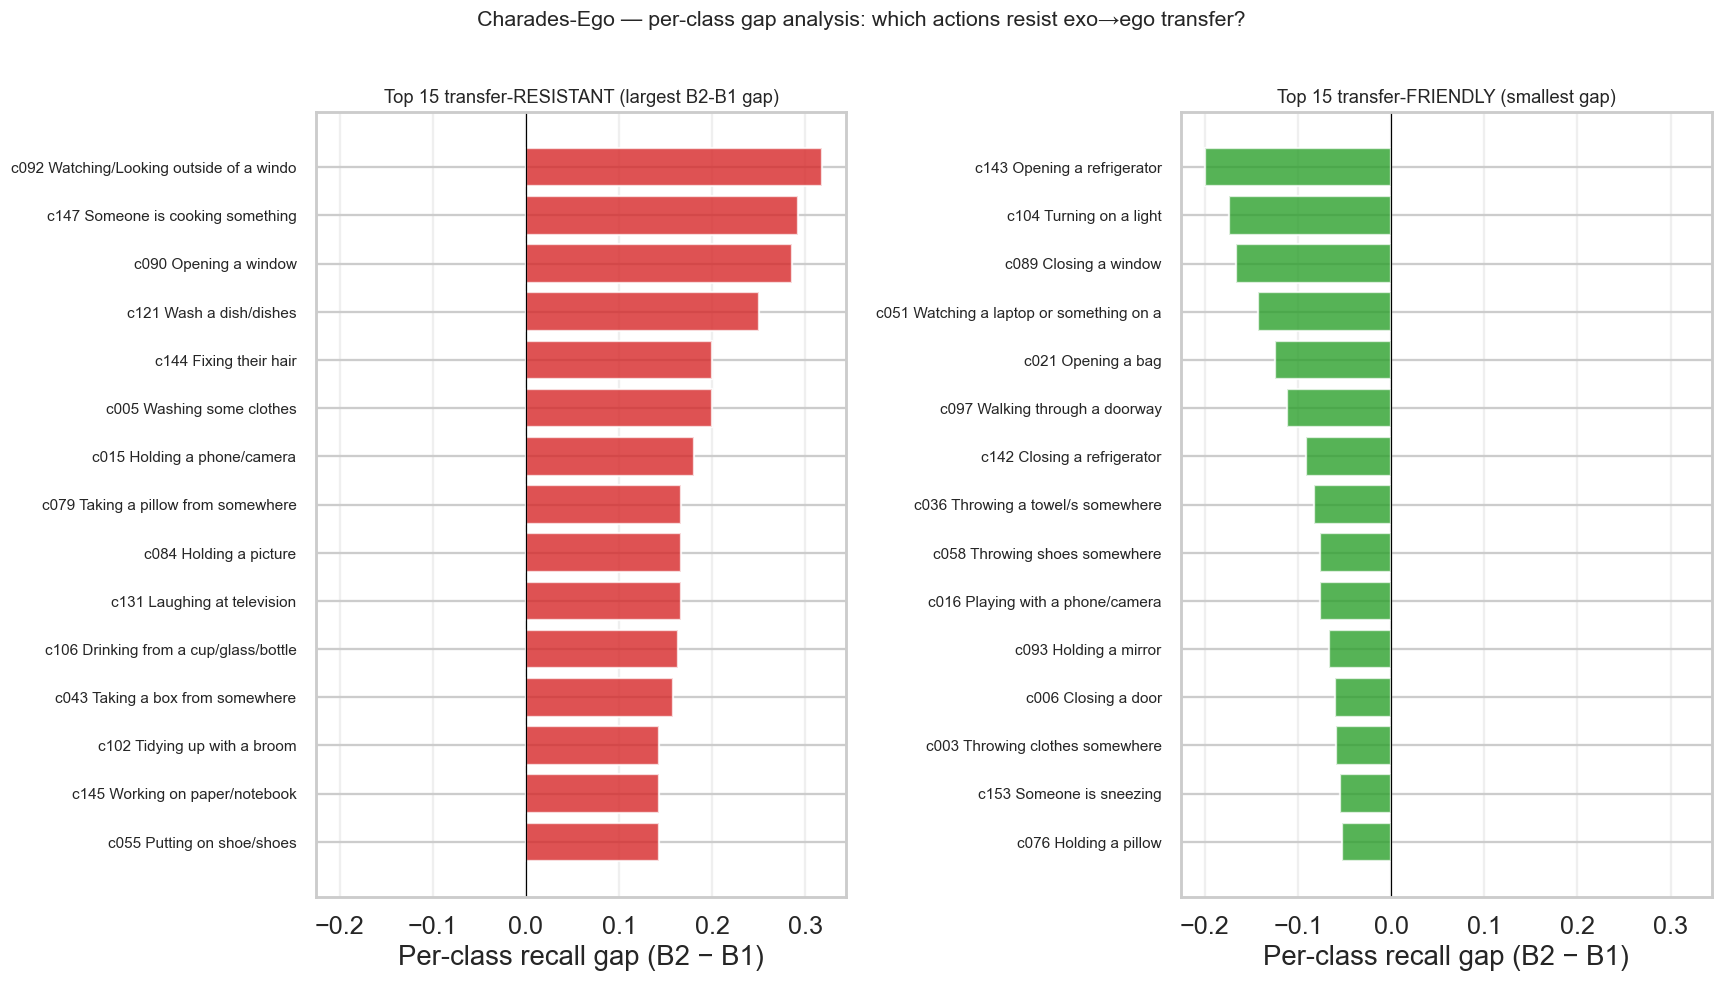

Saved: figures/12_per_class_gap.png

Top-5 most transfer-resistant actions (B2 reaches them but B1 doesn't):
  c092 Watching/Looking outside of a windo    gap=+0.318  (B1=0.000, B2=0.318, n_val=22)
  c147 Someone is cooking something           gap=+0.292  (B1=0.333, B2=0.625, n_val=24)
  c090 Opening a window                       gap=+0.286  (B1=0.000, B2=0.286, n_val=7)
  c121 Wash a dish/dishes                     gap=+0.250  (B1=0.062, B2=0.312, n_val=16)
  c144 Fixing their hair                      gap=+0.200  (B1=0.000, B2=0.200, n_val=15)

Top-5 most transfer-friendly actions (B2 - B1 ≤ 0, no real gap):
  c143 Opening a refrigerator                 gap=-0.200  (B1=0.600, B2=0.400, n_val=15)
  c104 Turning on a light                     gap=-0.174  (B1=0.174, B2=0.000, n_val=23)
  c089 Closing a window                       gap=-0.167  (B1=0.167, B2=0.000, n_val=6)
  c051 Watching a laptop or something on a    gap=-0.143  (B1=0.321, B2=0.179, n_val=28)
  c021 Opening a bag      

In [7]:
"""Figure 12 — per-class balanced accuracy gap (B2 - B1).
Highlights which actions are most viewpoint-resistant.
"""
from src.evaluation.metrics import aggregate_metrics

# get per-class predictions
preds_b1 = LOGITS["B1"].argmax(axis=1)
preds_b2 = LOGITS["B2"].argmax(axis=1)

# per-class recall = bal_acc per class component
per_class_b1 = []
per_class_b2 = []
for c in range(NUM_CLASSES):
    mask = (y_val == c)
    if mask.sum() == 0:
        per_class_b1.append(np.nan)
        per_class_b2.append(np.nan)
        continue
    per_class_b1.append(float((preds_b1[mask] == c).mean()))
    per_class_b2.append(float((preds_b2[mask] == c).mean()))

df = pd.DataFrame({
    "class_id": np.arange(NUM_CLASSES),
    "class_name": [class_names[c][:35] for c in range(NUM_CLASSES)],
    "b1_recall": per_class_b1,
    "b2_recall": per_class_b2,
})
df["gap"] = df["b2_recall"] - df["b1_recall"]
df["n_target_val"] = [int((y_val == c).sum()) for c in range(NUM_CLASSES)]
# keep only classes with at least a handful of target samples
df = df[df["n_target_val"] >= 5]

# top-15 with biggest gap (transfer-hostile) and top-15 with smallest/negative (transfer-friendly)
top_resistant = df.sort_values("gap", ascending=False).head(15)
top_friendly  = df.sort_values("gap", ascending=True).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 9), sharex=True)

for ax, sub, title, color in [
    (axes[0], top_resistant, "Top 15 transfer-RESISTANT (largest B2-B1 gap)", "#d62728"),
    (axes[1], top_friendly,  "Top 15 transfer-FRIENDLY (smallest gap)",        "#2ca02c"),
]:
    labels = [f"c{c:03d} {n}" for c, n in zip(sub["class_id"], sub["class_name"])]
    y_pos = np.arange(len(sub))
    ax.barh(y_pos, sub["gap"].values, color=color, alpha=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel("Per-class recall gap (B2 − B1)")
    ax.set_title(title, fontsize=12)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.grid(True, axis="x", alpha=0.3)

fig.suptitle("Charades-Ego — per-class gap analysis: which actions resist exo→ego transfer?",
             fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / "12_per_class_gap.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: figures/12_per_class_gap.png")
print(f"\nTop-5 most transfer-resistant actions (B2 reaches them but B1 doesn't):")
for _, r in top_resistant.head(5).iterrows():
    print(f"  c{r['class_id']:03d} {r['class_name']:38s} gap={r['gap']:+.3f}  (B1={r['b1_recall']:.3f}, B2={r['b2_recall']:.3f}, n_val={r['n_target_val']})")

print(f"\nTop-5 most transfer-friendly actions (B2 - B1 ≤ 0, no real gap):")
for _, r in top_friendly.head(5).iterrows():
    print(f"  c{r['class_id']:03d} {r['class_name']:38s} gap={r['gap']:+.3f}  (B1={r['b1_recall']:.3f}, B2={r['b2_recall']:.3f}, n_val={r['n_target_val']})")

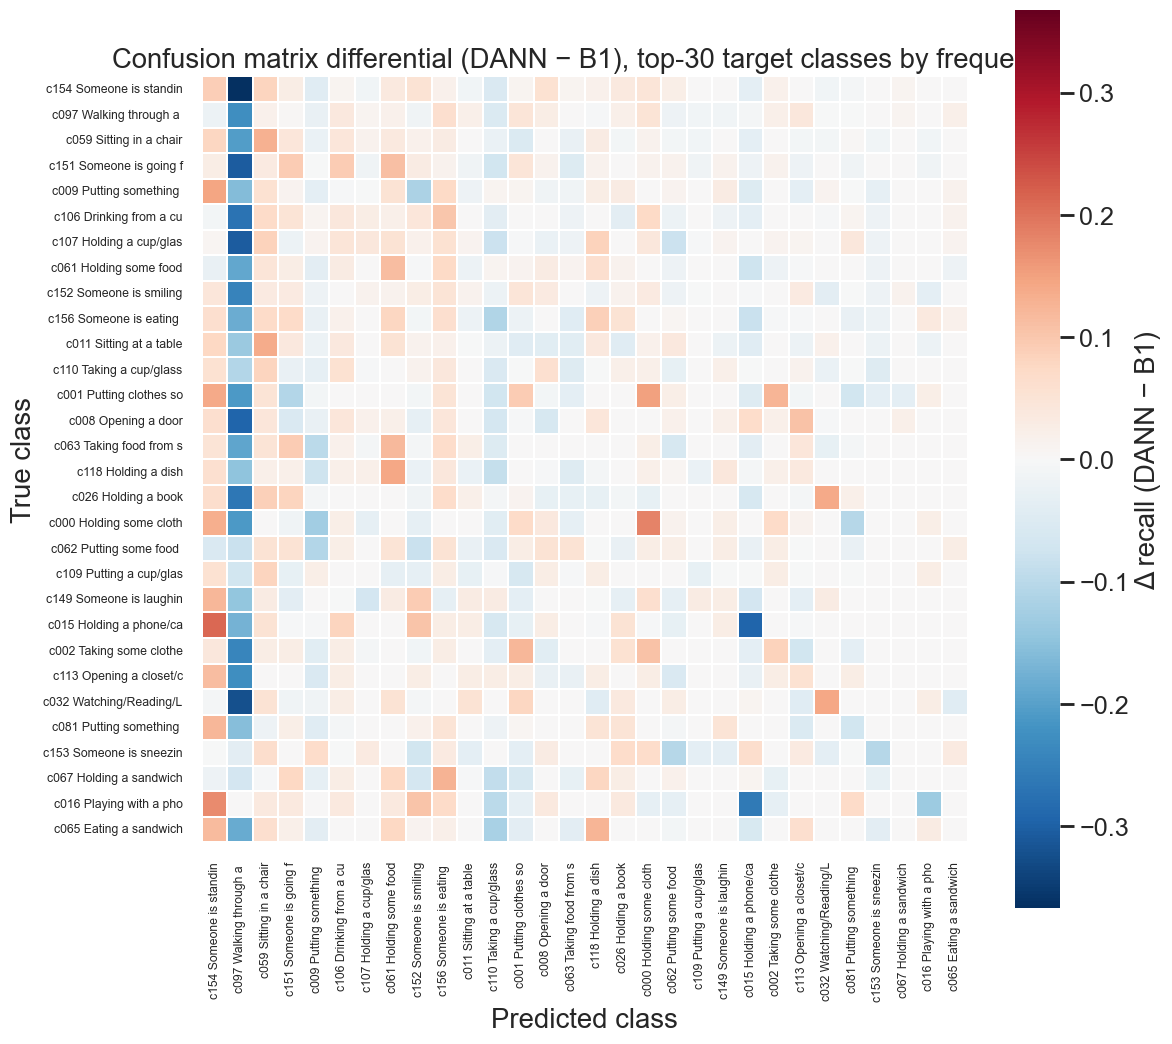

Saved: figures/13_confusion_differential.png

Diagonal stats (DANN gains where >0):
  classes where DANN gains: 15/30
  classes where DANN loses: 12/30
  mean diagonal Δ: +0.0060
  median diagonal Δ: +0.0121


In [8]:
"""Figure 13 — confusion matrix differential (CM_DANN - CM_B1).

Shows where DANN gains (positive cells on diagonal) and where it loses
(positive cells off-diagonal). For visual clarity, we restrict to the
top-30 most frequent classes in val_target.
"""
from sklearn.metrics import confusion_matrix

# Top-K most frequent target classes
K = 30
val_counts = pd.Series(y_val).value_counts().head(K)
top_classes = val_counts.index.values

mask = np.isin(y_val, top_classes)
y_sub = y_val[mask]
p_b1   = LOGITS["B1"].argmax(axis=1)[mask]
p_dann = LOGITS["DANN"].argmax(axis=1)[mask]

# Remap labels to dense indices 0..K-1
remap = {c: i for i, c in enumerate(top_classes)}
y_re   = np.array([remap[c] for c in y_sub])
p_b1_re   = np.array([remap[c] if c in remap else -1 for c in p_b1])
p_dann_re = np.array([remap[c] if c in remap else -1 for c in p_dann])

# Compute CM but restrict to predictions within top-K too (others lumped into "other")
def cm_topk(y_true, y_pred, K):
    cm = np.zeros((K, K), dtype=int)
    for t, p in zip(y_true, y_pred):
        if t < K and 0 <= p < K:
            cm[t, p] += 1
    return cm

cm_b1   = cm_topk(y_re, p_b1_re,   K)
cm_dann = cm_topk(y_re, p_dann_re, K)

# Normalise by row (recall-style)
cm_b1_n   = cm_b1   / np.clip(cm_b1.sum(axis=1, keepdims=True),   1, None)
cm_dann_n = cm_dann / np.clip(cm_dann.sum(axis=1, keepdims=True), 1, None)

cm_diff = cm_dann_n - cm_b1_n   # >0 means DANN > B1 in that cell

labels = [f"c{c:03d} {class_names[c][:18]}" for c in top_classes]

fig, ax = plt.subplots(figsize=(11, 10))
vmax = max(abs(cm_diff.min()), abs(cm_diff.max()))
sns.heatmap(cm_diff, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
            xticklabels=labels, yticklabels=labels,
            cbar_kws={"label": "Δ recall (DANN − B1)"},
            ax=ax, square=True, linewidths=0.1)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title(f"Confusion matrix differential (DANN − B1), top-{K} target classes by frequency")
plt.xticks(rotation=90, ha="center", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "13_confusion_differential.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: figures/13_confusion_differential.png")

# Quick analysis
diag = np.diag(cm_diff)
print(f"\nDiagonal stats (DANN gains where >0):")
print(f"  classes where DANN gains: {int((diag > 0).sum())}/{K}")
print(f"  classes where DANN loses: {int((diag < 0).sum())}/{K}")
print(f"  mean diagonal Δ: {diag.mean():+.4f}")
print(f"  median diagonal Δ: {np.median(diag):+.4f}")

In [9]:
"""Final cell: produce official numbers from best.pt for the REPORT.

These are the "true" best.pt evaluations (the trainer's "Final eval" message
was actually printing the LAST epoch's eval, not the best.pt's — a cosmetic
bug. The numbers below are the correct ones for the REPORT.)
"""
from src.evaluation.metrics import aggregate_metrics

print("=== Official numbers from best.pt (target val, 5135 segments) ===\n")
print(f"{'Model':<10s} {'balanced':>10s} {'top-1':>8s} {'top-5':>8s} {'macro-F1':>10s}")
print("-" * 50)

# rebuild and re-eval each model fresh (to be safe)
results = {}
for name, ckpt_path in MODELS.items():
    enc, cls, _, _, _ = build_from_ckpt(ckpt_path)
    with torch.no_grad():
        z = enc(X_val)
        logits = cls(z)
    m = aggregate_metrics(logits.cpu(), torch.from_numpy(y_val),
                          num_classes=NUM_CLASSES, is_logits=True)
    results[name] = m
    print(f"{name:<10s} {m['balanced_accuracy']:>10.4f} {m['top1']:>8.4f} "
          f"{m['top5']:>8.4f} {m['macro_f1']:>10.4f}")

print("\nMarkdown table (paste into REPORT.md, Section 4.3):\n")
print("| Model | balanced acc | top-1 | top-5 | macro-F1 |")
print("|---|---|---|---|---|")
print(f"| **B1 — Source-only** (exo → ego, zero-shot) | {results['B1']['balanced_accuracy']:.3f} | "
      f"{results['B1']['top1']:.3f} | {results['B1']['top5']:.3f} | "
      f"{results['B1']['macro_f1']:.3f} |")
print(f"| **DANN (λ_max = 0.5)** — main | **{results['DANN']['balanced_accuracy']:.3f}** | "
      f"**{results['DANN']['top1']:.3f}** | **{results['DANN']['top5']:.3f}** | "
      f"**{results['DANN']['macro_f1']:.3f}** |")
print(f"| **MMD (λ_mmd = 1.0)** — main | **{results['MMD']['balanced_accuracy']:.3f}** | "
      f"**{results['MMD']['top1']:.3f}** | **{results['MMD']['top5']:.3f}** | "
      f"**{results['MMD']['macro_f1']:.3f}** |")
print(f"| **B2 — Target-only oracle** (ego → ego, upper bound) | {results['B2']['balanced_accuracy']:.3f} | "
      f"{results['B2']['top1']:.3f} | {results['B2']['top5']:.3f} | "
      f"{results['B2']['macro_f1']:.3f} |")

=== Official numbers from best.pt (target val, 5135 segments) ===

Model        balanced    top-1    top-5   macro-F1
--------------------------------------------------
B1             0.0391   0.0460   0.1644     0.0297
DANN           0.0401   0.0539   0.1799     0.0321
MMD            0.0425   0.0553   0.1877     0.0372
B2             0.0683   0.0722   0.2483     0.0602

Markdown table (paste into REPORT.md, Section 4.3):

| Model | balanced acc | top-1 | top-5 | macro-F1 |
|---|---|---|---|---|
| **B1 — Source-only** (exo → ego, zero-shot) | 0.039 | 0.046 | 0.164 | 0.030 |
| **DANN (λ_max = 0.5)** — main | **0.040** | **0.054** | **0.180** | **0.032** |
| **MMD (λ_mmd = 1.0)** — main | **0.042** | **0.055** | **0.188** | **0.037** |
| **B2 — Target-only oracle** (ego → ego, upper bound) | 0.068 | 0.072 | 0.248 | 0.060 |
